In [25]:
import csv
import json
import os
import random
import time
from os import listdir
from os.path import isdir, join
from pathlib import Path

import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import random_split, DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, RandomHorizontalFlip, RandomCrop

from src.dataset import define_transformations
from src.experiment import save_model, save_results, save_config, prepare_results_dir
from src.metrics import plot_training_metrics
from src.training import training_loop


In [26]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [27]:
with open("../configs/base_config.json", encoding="utf-8") as file:
    config_json = json.load(file)

seed = int(config_json["seed"])

batch_size = int(config_json["data"]["batch_size"])
augmentation = config_json["data"]["augmentation"]

model = config_json["model"]["name"]
dropout = config_json["model"]["dropout"]

learning_rate = float(config_json["training"]["learning_rate"])
weight_decay = float(config_json["training"]["weight_decay"])
scheduler_config = config_json["training"]["scheduler"]
epochs = int(config_json["training"]["epochs"])

early_stopping_config = config_json["training"]["early_stopping"]
early_stopping_patience = int(early_stopping_config["patience"])
early_stopping_min_delta = float(early_stopping_config["min_delta"])

In [28]:
random.seed(seed)
torch.manual_seed(seed)

In [29]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [30]:
train_transform, val_transform = define_transformations(augmentation, IMAGENET_MEAN, IMAGENET_STD)

In [31]:
# Load training split for 37-class pet breed classification
train_dataset = OxfordIIITPet(
    root="../data",
    split="trainval",
    target_types="category",
    download=True,
    transform=train_transform
)
test_dataset = OxfordIIITPet(
    root="../data",
    split="test",
    target_types="category",
    download=True,
    transform=val_transform
)

In [32]:
train_split = random_split(train_dataset,
                     [0.7, 0.3],
                     generator=torch.Generator().manual_seed(seed))
train_loader = DataLoader(train_split[0], batch_size=batch_size, shuffle=True)
val_loader = DataLoader(train_split[1], batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [33]:
class MyAlexNet(nn.Module):
    def __init__(self, num_classes, dropout):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 96, 11, stride=4, padding=1)
        self.batchNorm1 = nn.BatchNorm2d(96)
        self.pool1 = nn.MaxPool2d(3, 2)

        self.conv2 = nn.Conv2d(96, 256, 5, stride=1, padding=2)
        self.batchNorm2 = nn.BatchNorm2d(256)
        self.pool2 = nn.MaxPool2d(3, 2)

        self.conv3 = nn.Conv2d(256, 384, 3, stride=1, padding=1)
        self.batchNorm3 = nn.BatchNorm2d(384)
        self.conv4 = nn.Conv2d(384, 384, 3, stride=1, padding=1)
        self.batchNorm4 = nn.BatchNorm2d(384)
        self.conv5 = nn.Conv2d(384, 256, 3, stride=1, padding=1)
        self.batchNorm5 = nn.BatchNorm2d(256)

        self.pool3 = nn.MaxPool2d(3, 2)

        self.relu = nn.ReLU()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(6400, 4096),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.relu(self.batchNorm1(self.conv1(x)))
        x = self.pool1(x)

        x = self.relu(self.batchNorm2(self.conv2(x)))
        x = self.pool2(x)

        x = self.relu(self.batchNorm3(self.conv3(x)))
        x = self.relu(self.batchNorm4(self.conv4(x)))
        x = self.relu(self.batchNorm5(self.conv5(x)))

        x = self.pool3(x)

        x = self.classifier(x)

        return x

In [34]:
num_classes = len(train_dataset.classes)
print(f"{num_classes} classes found.")

37 classes found.


In [35]:
verify_simple_cnn = MyAlexNet(num_classes=10, dropout=0.5)
print("Model Structure:\n")
print(verify_simple_cnn)

Model Structure:

MyAlexNet(
  (conv1): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4), padding=(1, 1))
  (batchNorm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (batchNorm2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batchNorm3): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv4): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batchNorm4): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv5): Conv2d(384, 256, kernel_size=(3, 3), stride

In [36]:
# Create a dummy input tensor (batch_size=64, channels=3, height=32, width=32)
dummy_input = torch.randn(64, 3, 224, 224)
print(f"\nInput tensor shape:  {dummy_input.shape}")
# Pass the dummy tensor through the model
output = verify_simple_cnn(dummy_input)
print(f"Output tensor shape: {output.shape}")


Input tensor shape:  torch.Size([64, 3, 224, 224])
Output tensor shape: torch.Size([64, 10])


In [37]:
model = MyAlexNet(num_classes=num_classes, dropout=dropout)

In [38]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode=scheduler_config["mode"],
    factor=float(scheduler_config["factor"]),
    patience=int(scheduler_config["patience"]),
    min_lr=float(scheduler_config["min_lr"]),
)

In [39]:
# def prepare_results_dir():
#     results_dir = "../experiments"
#     Path(results_dir).mkdir(parents=True, exist_ok=True)
#     experiment_numbers = [
#         int(name) for name in listdir(results_dir)
#             if name.isdigit() and isdir(join(results_dir, name))
#     ]
#     exp_number = max(experiment_numbers, default=0) + 1
#     exp_path = join(results_dir, str(exp_number))
#     Path(exp_path).mkdir(parents=True, exist_ok=True)
#     return results_dir, exp_number, exp_path

In [40]:
results_dir, exp_number, exp_path = prepare_results_dir()
print("Results Directory:", results_dir)
print("Experiment Number:", exp_number)
print("Experiment Path:", exp_path)

Results Directory: experiments
Experiment Number: 1
Experiment Path: experiments/1


In [42]:
save_config(exp_path, config_json)

In [43]:
trained_model, training_metrics = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=epochs,
    device=device,
    scheduler=scheduler,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta
)

--- Training Started ---
Epoch [1/10], Train Loss: 3.8447, Train Accuracy: 3.73% Val Loss: 3.5508, Val Accuracy: 4.26%
Epoch [2/10], Train Loss: 3.5583, Train Accuracy: 4.93% Val Loss: 3.5520, Val Accuracy: 5.53%
Epoch [3/10], Train Loss: 3.5086, Train Accuracy: 5.63% Val Loss: 3.5306, Val Accuracy: 4.80%
Epoch [4/10], Train Loss: 3.5043, Train Accuracy: 6.17% Val Loss: 3.5849, Val Accuracy: 4.35%
Epoch [5/10], Train Loss: 3.4786, Train Accuracy: 7.26% Val Loss: 3.4705, Val Accuracy: 6.52%
Epoch [6/10], Train Loss: 3.4709, Train Accuracy: 6.41% Val Loss: 3.4651, Val Accuracy: 7.07%
Epoch [7/10], Train Loss: 3.4461, Train Accuracy: 7.22% Val Loss: 3.4547, Val Accuracy: 5.25%
Epoch [8/10], Train Loss: 3.4395, Train Accuracy: 7.03% Val Loss: 3.4752, Val Accuracy: 7.52%
Epoch [9/10], Train Loss: 3.4233, Train Accuracy: 7.80% Val Loss: 3.4156, Val Accuracy: 6.97%
Epoch [10/10], Train Loss: 3.4232, Train Accuracy: 7.26% Val Loss: 3.4172, Val Accuracy: 7.61%
--- Finished Training ---

--- Ret


--- Training Plots ---



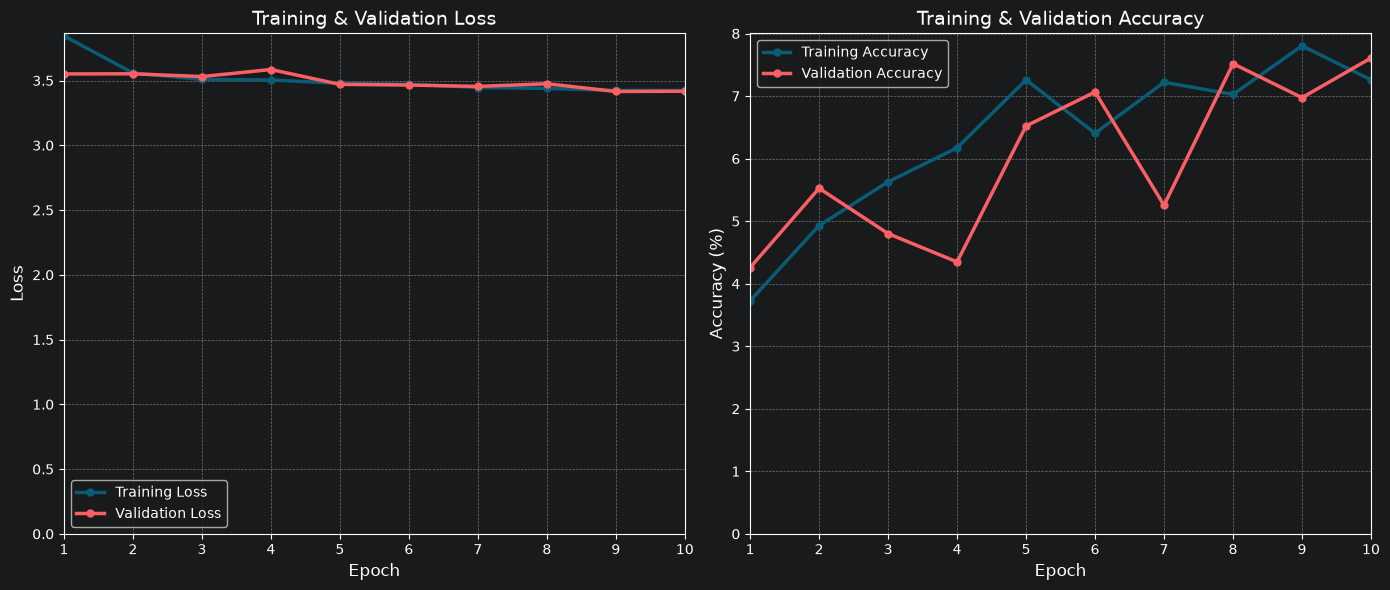

In [44]:
print("\n--- Training Plots ---\n")
plot_training_metrics(training_metrics, exp_path)

In [46]:
save_results(results_dir,
             exp_path,
             exp_number,
             learning_rate,
             training_metrics,
             model.__class__.__name__,
             len(training_metrics[0]),
             batch_size,
             optimizer.__class__.__name__,
             weight_decay,
             seed,
             str(augmentation),
             dropout,
             scheduler_config
             )

In [47]:
save_model(exp_path, model)